In [1]:
%load_ext autoreload
%autoreload 2

# Machine Unlearning on MNIST

The goal is to deploy a toy unlearning method over MNIST, for education purposes.

# First, train an MNIST classifier

### Imports

In [2]:
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils.prune as prune

import numpy as np
import matplotlib.pyplot as plt
import copy

import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
import psutil
import os

%matplotlib inline

# Data

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip


/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


X shape = torch.Size([128, 3, 32, 32])
Sample y: tensor([5, 3, 1, 7, 7, 5, 5, 7, 8, 1])


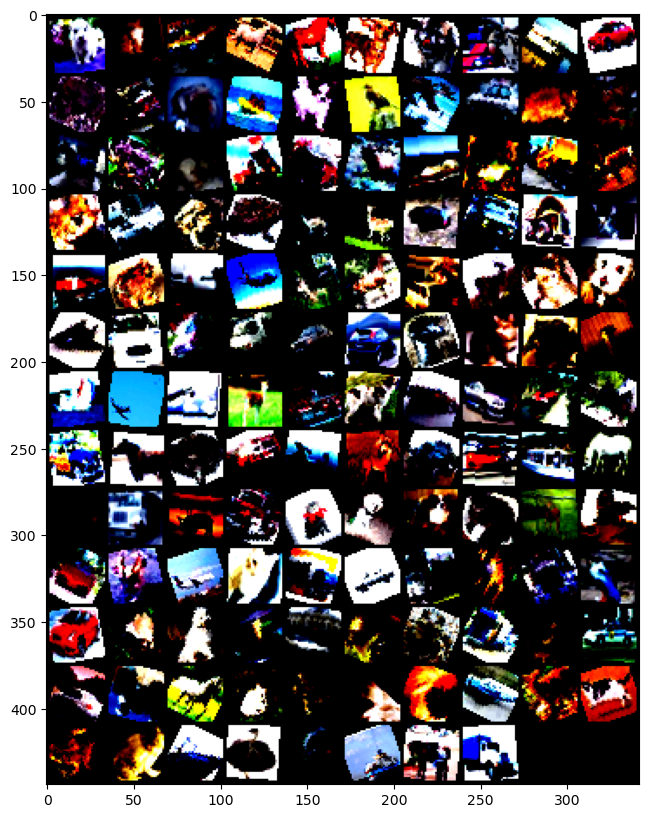

In [3]:
from data.dataset import cifar10_dataloaders

def get_next_batch(loader):
    
    X, y = next(iter(loader))

    return X, y

def check_test_accuracy(model, device):
    
    model.eval()
    num_correct = 0
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        with torch.no_grad(): # Gradients aren't needed just for test evaluation
            y_hat = model(X).argmax(-1)
        num_correct += (y_hat == y).cpu().numpy().sum()
    return num_correct / len(test_loader)

train_loader, val_loader, test_loader = cifar10_dataloaders(batch_size = 128, data_dir = "data/CIFAR10", num_workers = 4, no_aug = False)

# shape of data
X, y = get_next_batch(train_loader)
print(f'X shape = {X.shape}')
print(f"Sample y: {y[:10]}")

# visualize some photos
plt.figure(figsize=(18,10))
plt.imshow(make_grid(X, nrow=10).permute((1,2,0)));

# Model

In [4]:
class ConvNet(nn.Module):
    def __init__(self, input_dims = 3, frame_size = 32):
        """
        """
        super().__init__()
        self.input_dims = input_dims
        self.frame_size = frame_size

        self.conv = nn.Sequential(

            # 28x28 -> 14x14
            nn.Conv2d(self.input_dims, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d( (2, 2) ),
            nn.Dropout(.2),

            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d( (2, 2)),
            nn.Dropout(.2),

            # 7x7 -> 4x4
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d( (2, 2) ),
            nn.Dropout(.2),
            
            # 4x4 -> 2x2
            nn.Conv2d(256, 512, 3, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(.2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.flatten = nn.Flatten() # some dim, depending on input_dim
        
        # the size of the cnn output
        with torch.no_grad():
            dummy_in = torch.zeros(1, self.input_dims, self.frame_size, self.frame_size)
            dummy_out = self.conv(dummy_in)
            n_flat = self.flatten(dummy_out).shape[1]

        # This will be the first hidden layer
        self.head = nn.Sequential(
            nn.Linear(n_flat, 128),
            nn.Dropout(.3),
            nn.ReLU(),
            nn.Linear(128, 10)
            )
        
    def forward(self, X):
        """
        The actual forward computation is defined here. This is run whenever you "call" the
        `nn.Module`, after it is instantiated.
        
        Here we will write down the computation required to run the model forward, calling
        our previously defined subnetworks
        
        """
        
        # B, C, H, W = X.shape

        x = self.conv(X)
        x = self.flatten(x)
        y = self.head(x)
        return y

# Training

In [5]:
def get_model_weight_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.requires_grad:
            # L2 Norm: square the values, sum them, and take the square root
            param_norm = p.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def get_memory_footprint():
    """Returns the current System RAM and GPU VRAM usage."""
    
    # System RAM
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / ( 1024**3 )
    
    # GPU VRAM usage
    vram_gb = 0.0
    if torch.cuda.is_available():
        # memory_allocated is the actual tensor storage
        # memory_reserved includes the cache held by PyTorch
        vram_gb = torch.cuda.memory_reserved() / (1024**3)
    elif torch.backends.mps.is_available():
        # Using driver_allocated because it reflects the actual 
        # hardware pressure on the Unified Memory pool.
        vram_gb = torch.mps.driver_allocated_memory() / (1024**3)
        
    return ram_gb, vram_gb

def evaluate(model, data_loader, criterion, device, print_predictions = False):
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        
        # for each batch...
        for data, target in data_loader:
            
            # ... send to the right device,
            data, target = data.to(device), target.to(device)

            # ... fix targets to align with model outputs,
            # target = target.long() - 1

            # ... send data through the model,
            outputs = model(data)

            # ... calculate and update loss,
            total_loss += criterion( outputs , target ).item()

            # ... predict most likely class, 
            _, preds = torch.max(outputs, 1)
            
            # ... and tally accuracy.
            correct += (preds == target).sum().item()
            total += target.size(0)
            if print_predictions:
                print(f"Sample Preds: {preds[:5].cpu().numpy() + 1}")

    return total_loss / len(data_loader), correct / total

def training_regimen(model, train_loader, val_loader, opt, criterion, scheduler, device, num_epochs = 10, best_val_loss = torch.inf, model_path = "model_checkpoints/best_CIFAR10_model.pth"):
    
    # For each epoch ...
    for k in range(num_epochs):


        print(f" ----- EPOCH {k} ----- \n")
        # ... grab the current learning rate, 
        current_lr = opt.param_groups[0]["lr"]

        # ... train one epoch
        for i, (X, y) in enumerate(train_loader):
            
            X, y = X.to(device), y.to(device)
            
            opt.zero_grad() # zero gradients
            y_hat = model(X) # forward pass
            loss = criterion(y_hat, y)
            loss.backward()
            opt.step()

            if i % 100 == 0:
                print(f"Batch {i}: Loss = {loss.cpu().item():.4f}")
 
        # ... eval on validation set
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # ... step scheduler
        scheduler.step(val_loss)

        # ... and message if learning rate changed for the next epoch
        new_lr = opt.param_groups[0]['lr']
        if new_lr < current_lr:
            print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        if new_lr < 1e-6:
            print(f"\n[EARLY STOPPING] LR {new_lr:.1e} is below threshold. Training halted.")
            break

        # ... track metrics
        # ... track model metrics,
        ram, vram = get_memory_footprint()
        current_norm = get_model_weight_norm(model)

        # ... message how we're doing
        print(f"Epoch {k} | LR: {current_lr:.1e} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f} | "
              f"RAM: {ram:.2f}GB | VRAM: {vram:.2f}GB | Weight Norm: {current_norm:.3f}")

        # ... and if this is the best so far, save out

        # ... and, if this is the best model so far, save it.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            
            checkpoint = {
                'epoch': k,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': opt.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
            }
            
            torch.save(checkpoint, model_path, _use_new_zipfile_serialization = False)
            print(f"--- Epoch {k}: New best model saved! ---")
        
    return model, opt, scheduler


# Train and Predict on Test

In [6]:
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
classifier = ConvNet(input_dims=3, frame_size=32).to(device)
num_params = sum([a.numel() for a in classifier.parameters()])
print(f"Number of model parameters: {num_params:,}")
opt = optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay = 7e-4)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2, threshold = .01, threshold_mode = "rel")
model, opt, scheduler = training_regimen(classifier, train_loader, val_loader, opt, criterion, scheduler, device, num_epochs=50, model_path = "model_checkpoints/best_CIFAR10_model.pth")

Number of model parameters: 1,619,850
 ----- EPOCH 0 ----- 

Batch 0: Loss = 2.3213
Batch 100: Loss = 1.5702
Batch 200: Loss = 1.5572
Batch 300: Loss = 1.4793
Epoch 0 | LR: 1.0e-03 | Val Loss: 1.3312, Val Acc: 0.52 | RAM: 0.57GB | VRAM: 1.18GB | Weight Norm: 43.373
--- Epoch 0: New best model saved! ---
 ----- EPOCH 1 ----- 

Batch 0: Loss = 1.2697
Batch 100: Loss = 1.2436
Batch 200: Loss = 1.1496
Batch 300: Loss = 1.3213
Epoch 1 | LR: 1.0e-03 | Val Loss: 1.1665, Val Acc: 0.58 | RAM: 0.55GB | VRAM: 1.12GB | Weight Norm: 48.331
--- Epoch 1: New best model saved! ---
 ----- EPOCH 2 ----- 

Batch 0: Loss = 1.1439
Batch 100: Loss = 0.9521
Batch 200: Loss = 1.1938
Batch 300: Loss = 0.9923
Epoch 2 | LR: 1.0e-03 | Val Loss: 1.0558, Val Acc: 0.61 | RAM: 0.44GB | VRAM: 1.12GB | Weight Norm: 52.435
--- Epoch 2: New best model saved! ---
 ----- EPOCH 3 ----- 

Batch 0: Loss = 1.0723
Batch 100: Loss = 0.9539
Batch 200: Loss = 0.9529
Batch 300: Loss = 0.8077
Epoch 3 | LR: 1.0e-03 | Val Loss: 1.0397

# Bigger evaluation on val set

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# More comprehensive model evaluation (no transformations)
def full_evaluate(model, data_loader, device):
    
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_times = []

    print("\n")

    with torch.no_grad():
        # for each batch, ...
        for idx, (X, labels) in enumerate(data_loader):
            
            # ... grab the data
            X, labels = X.to(device), labels.to(device)

            outputs = model(X)
            
            # ... make predictions
            _, preds = torch.max(outputs, 1)
            

            # ... evalute if we're correct or not
            for i in range(labels.size(0)):
                batch_idx = idx * data_loader.batch_size + i
                pred = preds[i].item()
                true_label = labels[i].item()
                is_correct = "✓" if pred == true_label else "✗"
                print(f"{is_correct}  pred={pred}  true={true_label}  |  {i}")

            # ... tally our results
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Now, generate a confusion matrix of all our incorrect predictions, ...
    unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plot_confusion_matrix(cm, unique_labels)

    # ... and tally our final accuracy
    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_times

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Classifications')
    plt.show()
    
def run_inference(model, data_loader):

    model = model.to(device)

    # Create dataloader

    print(f"\nRunning inference on {len(data_loader)} test items...")
    accuracy, preds, labels, times = full_evaluate(model, data_loader, device)

    # Summary
    num_correct = sum(p == l for p, l in zip(preds, labels))
    num_wrong = len(preds) - num_correct

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Total items:         {len(preds)}")
    print(f"Correct:              {num_correct}")
    print(f"Incorrect:                {num_wrong}")
    print(f"")
    print(f"ACCURACY:             {accuracy*100:.2f}%")
    print(f"")
    print("="*50)
    return accuracy, preds, labels


Successfully loaded model from epoch 24

Running inference on 40 test items...


✓  pred=0  true=0  |  0
✓  pred=0  true=0  |  1
✗  pred=4  true=0  |  2
✗  pred=9  true=0  |  3
✓  pred=0  true=0  |  4
✓  pred=0  true=0  |  5
✓  pred=0  true=0  |  6
✓  pred=0  true=0  |  7
✓  pred=0  true=0  |  8
✗  pred=6  true=0  |  9
✓  pred=0  true=0  |  10
✓  pred=0  true=0  |  11
✓  pred=0  true=0  |  12
✓  pred=0  true=0  |  13
✓  pred=0  true=0  |  14
✗  pred=7  true=0  |  15
✓  pred=0  true=0  |  16
✓  pred=0  true=0  |  17
✓  pred=0  true=0  |  18
✓  pred=0  true=0  |  19
✓  pred=0  true=0  |  20
✓  pred=0  true=0  |  21
✓  pred=0  true=0  |  22
✓  pred=0  true=0  |  23
✓  pred=0  true=0  |  24
✗  pred=2  true=0  |  25
✓  pred=0  true=0  |  26
✓  pred=0  true=0  |  27
✓  pred=0  true=0  |  28
✗  pred=8  true=0  |  29
✓  pred=0  true=0  |  30
✓  pred=0  true=0  |  31
✓  pred=0  true=0  |  32
✓  pred=0  true=0  |  33
✓  pred=0  true=0  |  34
✗  pred=3  true=0  |  35
✓  pred=0  true=0  |  36
✓  p

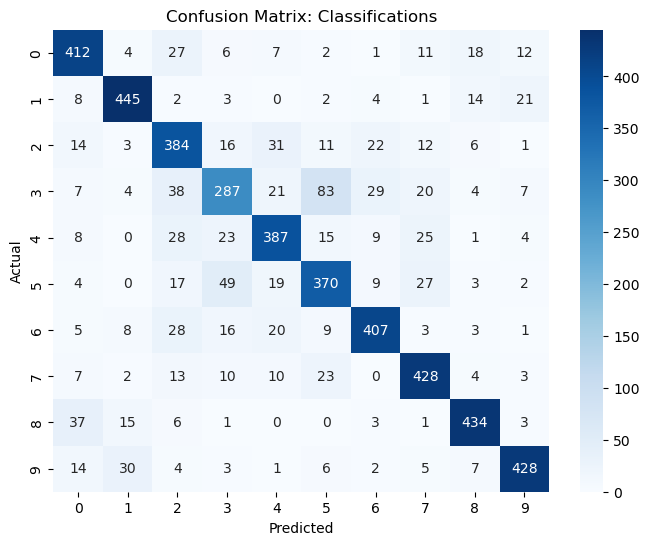


SUMMARY
Total items:         5000
Correct:              3982
Incorrect:                1018

ACCURACY:             79.64%



In [8]:
model = ConvNet(input_dims=3, frame_size=32)
checkpoint = torch.load('model_checkpoints/best_CIFAR10_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Successfully loaded model from epoch {checkpoint['epoch']}")
model.eval()
model.to(device)
torch.manual_seed(0)
_, _, _ = run_inference(model, val_loader)

# Inspecting suspicious outputs

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


tensor([[0.0000, 0.0000, 0.0000, 0.9890, 0.0000, 0.0100, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0020, 0.0000, 0.0050, 0.4310, 0.0040, 0.5290, 0.0040, 0.0250, 0.0000, 0.0010],
        [0.0000, 0.0000, 0.0000, 0.9900, 0.0060, 0.0040, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0010, 0.0010, 0.0000, 0.6630, 0.0000, 0.0050, 0.0300, 0.0000, 0.2990, 0.0010],
        [0.0000, 0.0000, 0.0370, 0.8850, 0.0110, 0.0400, 0.0090, 0.0170, 0.0000, 0.0000],
        [0.0000, 0.0020, 0.0000, 0.8980, 0.0070, 0.0730, 0.0040, 0.0130, 0.0000, 0.0020],
        [0.0000, 0.0000, 0.0990, 0.6030, 0.0040, 0.2830, 0.0000, 0.0100, 0.0000, 0.0000],
        [0.0510, 0.0000, 0.6840, 0.1270, 0.0010, 0.0760, 0.0000, 0.0520, 0.0000, 0.0080]])


tensor([3, 5, 3, 3, 3, 3, 3, 2])

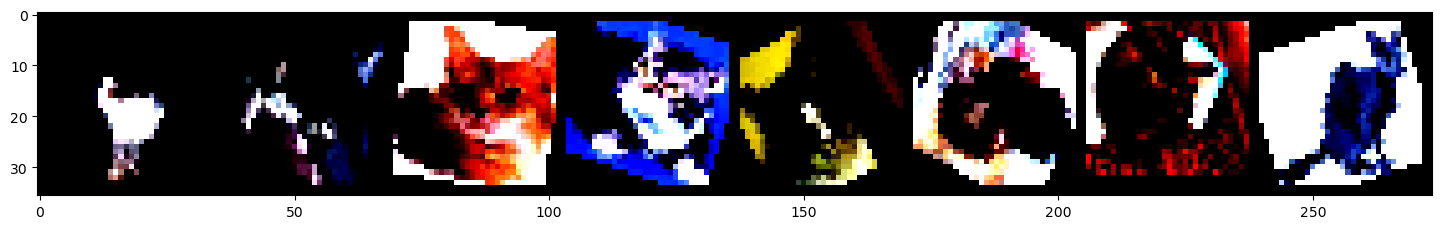

In [17]:
X, y = get_next_batch(train_loader)
idx_where_cat = np.argwhere(y == 3)

subset = X[idx_where_cat].squeeze()
plt.figure(figsize=(18,10))
plt.imshow(make_grid(subset, nrow=10).permute((1,2,0)));
model.cpu()
outputs = model(X[idx_where_cat].squeeze()).detach()
print(torch.round( torch.softmax(outputs, dim = 1), decimals = 3))
torch.argmax(outputs, dim = 1)